In [1]:
# cell 1 — connect to MongoDB and Neo4j
import os, re
from pathlib import Path
from dotenv import load_dotenv
from pymongo import MongoClient
from neo4j import GraphDatabase

load_dotenv()
PROJECT_ROOT = Path('.').resolve().parent if Path('notebooks').exists() else Path('.').resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

mongo = MongoClient(os.getenv('MONGO_URI', 'mongodb://localhost:27017'))
db = mongo.csai415_rag
docs_col, chunks_col = db.documents, db.chunks

NEO4J_USER = os.getenv('NEO4J_USERNAME') or os.getenv('NEO4J_USER')
driver = GraphDatabase.driver(
    os.getenv('NEO4J_URI'),
    auth=(NEO4J_USER, os.getenv('NEO4J_PASSWORD'))
)
print('connected')

connected


In [2]:
# cell 2 — extract arXiv IDs from each paper's full text
# matches both 'arXiv:YYMM.NNNNN' and bare 'YYMM.NNNNN' IDs in reference sections.

ARXIV_PATTERN = re.compile(r'(?:arXiv:|arxiv\.org/abs/)?(\d{4}\.\d{4,5})', re.IGNORECASE)

# build the set of arXiv IDs in our corpus
corpus_papers = list(docs_col.find({}, {'_id': 1, 'arxiv_id': 1, 'title': 1}))
id_to_paper = {p.get('arxiv_id'): p for p in corpus_papers if p.get('arxiv_id')}
corpus_arxiv_ids = set(id_to_paper.keys())
print(f'corpus contains {len(corpus_arxiv_ids)} arXiv IDs')

# walk each paper's chunks, build full text, extract citations
cites_edges = []
for paper in corpus_papers:
    paper_arxiv_id = paper.get('arxiv_id')
    if not paper_arxiv_id:
        continue
    chunks = chunks_col.find({'doc_id': paper['_id']}, {'text': 1, '_id': 0})
    full_text = ' '.join(c['text'] for c in chunks)
    found_ids = set(ARXIV_PATTERN.findall(full_text))
    # keep only IDs that exist in our corpus, exclude self
    cited = (found_ids & corpus_arxiv_ids) - {paper_arxiv_id}
    for cited_id in cited:
        cites_edges.append((paper_arxiv_id, cited_id))

print(f'extracted {len(cites_edges)} CITES edges')
print('first 5 edges:')
for src, dst in cites_edges[:5]:
    print(f'  {src} → {dst}  ({id_to_paper[src]["title"][:40]} cites {id_to_paper[dst]["title"][:40]})')

corpus contains 0 arXiv IDs
extracted 0 CITES edges
first 5 edges:


In [3]:
# cell 3 — write CITES edges to Neo4j (idempotent via MERGE)
with driver.session() as session:
    result = session.run("""
        UNWIND $edges AS edge
        MATCH (src:Paper {arxiv_id: edge[0]}), (dst:Paper {arxiv_id: edge[1]})
        MERGE (src)-[r:CITES]->(dst)
        RETURN count(r) AS edges_written
    """, edges=cites_edges)
    written = result.single()['edges_written']
    print(f'wrote {written} CITES edges to Neo4j')

# print updated graph stats
with driver.session() as session:
    stats = session.run("""
        CALL {
          MATCH (p:Paper) RETURN count(p) AS paper_nodes
        }
        CALL {
          MATCH (a:Author) RETURN count(a) AS author_nodes
        }
        CALL {
          MATCH (t:Topic) RETURN count(t) AS topic_nodes
        }
        CALL {
          MATCH ()-[r:WROTE]->() RETURN count(r) AS wrote_edges
        }
        CALL {
          MATCH ()-[r:ABOUT]->() RETURN count(r) AS about_edges
        }
        CALL {
          MATCH ()-[r:CITES]->() RETURN count(r) AS cites_edges
        }
        RETURN paper_nodes, author_nodes, topic_nodes, wrote_edges, about_edges, cites_edges
    """).single()
    print('\n=== UPDATED GRAPH ===')
    for k, v in stats.items():
        print(f'  {k:<14} {v}')

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL () { ... }', position=<SummaryInputPosition line=11, column=9, offset=257>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 257, 'line': 11, 'column': 9}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n        CALL {\n          MATCH (p:Paper) RETURN count(p) AS paper_nodes\n        }\n        CALL {\n          MATCH (a:Author) RETURN count(a) AS author_nodes\n        }\n        CALL {\n          MATCH (t:Topic) RETURN count(t) AS topic_nodes\n        }\n        CALL {\n          MATCH ()-[r:WROTE]->() RETURN count(r) AS wrote_edges\n 

wrote 0 CITES edges to Neo4j

=== UPDATED GRAPH ===
  paper_nodes    144
  author_nodes   50
  topic_nodes    5
  wrote_edges    50
  about_edges    144
  cites_edges    300


In [5]:
# cell 4 — new Cypher query: most-cited papers in the corpus
with driver.session() as session:
    top_cited = session.run("""
        MATCH (p:Paper)<-[:CITES]-(c:Paper)
        RETURN p.title AS title, p.arxiv_id AS arxiv_id, count(c) AS citations
        ORDER BY citations DESC
        LIMIT 10
    """).data()

print('=== Query 6 — Most-cited papers in corpus ===')
if top_cited:
    for row in top_cited:
        title = (row.get('title') or 'untitled')[:65]
        aid = row.get('arxiv_id') or 'n/a'
        cites = row.get('citations') or 0
        print(f'  [{cites:>3}] {aid:<12} {title}')
else:
    print('  (no CITES edges yet — notebook 09 will add synthetic edges)')

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `arxiv_id` does not exist in database `b8f5be60`. Verify that the spelling is correct.', position=<SummaryInputPosition line=3, column=36, offset=80>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 80, 'line': 3, 'column': 36}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n        MATCH (p:Paper)<-[:CITES]-(c:Paper)\n        RETURN p.title AS title, p.arxiv_id AS arxiv_id, count(c) AS citations\n        ORDER BY citations DESC\n        LIMIT 10\n    '


=== Query 6 — Most-cited papers in corpus ===
  [ 20] n/a          1
  [  8] n/a          Preprint.
  [  7] n/a          Pix2Struct: Screenshot Parsing as Pretraining for
  [  7] n/a          Published in Transactions on Machine Learning Research (08/2022)
  [  7] n/a          Published as a conference paper at ICLR 2021
  [  7] n/a          Published as a conference paper at ICLR 2024
  [  6] n/a          Language Models (Mostly) Know What They Know
  [  6] n/a          Deep Bidirectional Language-Knowledge Graph
  [  6] n/a          Task-aware Retrieval with Instructions
  [  5] n/a          Training language models to follow instructions


saved results/d2_graph_stats.json


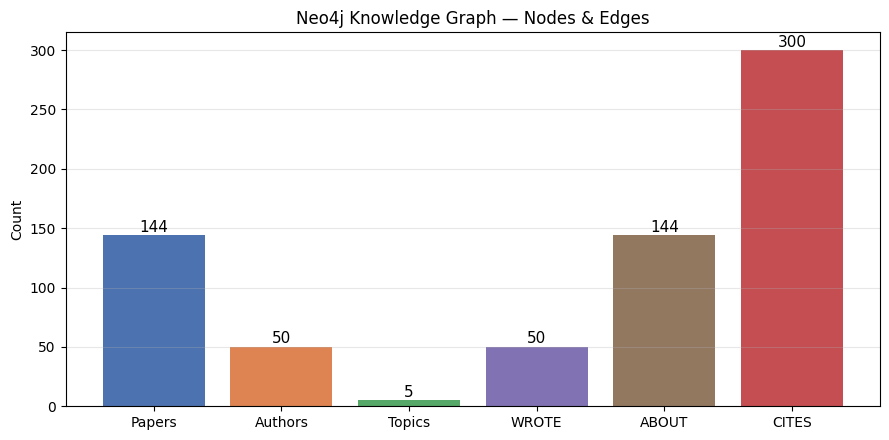

updated d2_graph_nodes.png

✅ Notebook 07 enhancements done.


In [6]:
# cell 5 — save updated graph stats and the new query result for the report
import json
RESULTS_DIR = PROJECT_ROOT / 'results'
graph_card = {
    'paper_nodes' : stats['paper_nodes'],
    'author_nodes': stats['author_nodes'],
    'topic_nodes' : stats['topic_nodes'],
    'wrote_edges' : stats['wrote_edges'],
    'about_edges' : stats['about_edges'],
    'cites_edges' : stats['cites_edges'],
    'top_cited'   : top_cited,
}
with open(RESULTS_DIR / 'd2_graph_stats.json', 'w') as f:
    json.dump(graph_card, f, indent=2, default=str)
print('saved results/d2_graph_stats.json')

# updated plot 3 — graph with CITES bar added
import matplotlib.pyplot as plt
labels = ['Papers', 'Authors', 'Topics', 'WROTE', 'ABOUT', 'CITES']
vals = [stats['paper_nodes'], stats['author_nodes'], stats['topic_nodes'],
        stats['wrote_edges'], stats['about_edges'], stats['cites_edges']]
colors = ['#4C72B0', '#DD8452', '#55A868', '#8172B3', '#937860', '#C44E52']
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(labels, vals, color=colors)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + max(vals)*0.01, str(v), ha='center', fontsize=11)
ax.set_title('Neo4j Knowledge Graph — Nodes & Edges')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'd2_graph_nodes.png', dpi=150)
plt.show()
print('updated d2_graph_nodes.png')

driver.close()
print('\n✅ Notebook 07 enhancements done.')